# MARL Warehouse Placement Simulation bằng Gymnasium + PPO

Notebook này là bản **đã sửa lại hoàn chỉnh** để tránh các lỗi `PettingZoo/SuperSuit` như `render_mode`, `max_steps`, `service_radius`.

Cách làm trong notebook này:

- Dùng **Gymnasium** để xây dựng môi trường mô phỏng.
- Mỗi kho ứng viên được xem như một **agent**.
- Action là vector nhiều agent: mỗi agent chọn `0 = đóng kho`, `1 = mở kho`.
- Dùng **PPO** của Stable-Baselines3 để train chính sách cooperative MARL-style.
- Có trực quan hóa bản đồ kho, khách hàng, đường phục vụ và biểu đồ reward.

> Ghi chú: Đây là cách tiếp cận **centralized cooperative MARL-style**. Tức là nhiều warehouse-agent cùng ra quyết định trong một action vector, nhưng train bằng một policy PPO ổn định để tránh lỗi framework phức tạp khi chạy Colab.

## 1. Cài đặt thư viện

Chạy cell này trước. Nếu Colab yêu cầu restart runtime sau khi install thì bấm restart rồi chạy lại từ đầu.

In [ ]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================

!pip -q install "gymnasium>=0.29.1" "stable-baselines3>=2.3.2" matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 14.9 MB/s eta 0:00:00


## 2. Import thư viện

In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print("Imports OK")

Imports OK


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Môi trường mô phỏng đặt kho bằng Gymnasium

Trong môi trường này:

- Có `n_warehouses` kho ứng viên.
- Có `n_customers` khách hàng/demand points.
- Mỗi kho là một agent.
- Action là vector `MultiBinary(n_warehouses)`.
- Ví dụ action `[1, 0, 1, 0]` nghĩa là mở kho 0 và kho 2, đóng kho 1 và kho 3.

In [ ]:
# ============================================================
# GYMNASIUM ENV: Cooperative Multi-Agent Warehouse Placement
# ============================================================

class WarehousePlacementGymEnv(gym.Env):
    """
    Gymnasium environment cho bài toán cooperative MARL-style warehouse placement.

    Ý tưởng:
    - Mỗi warehouse ứng viên là 1 agent.
    - Action space: MultiBinary(n_warehouses)
        action[i] = 1 -> mở warehouse i
        action[i] = 0 -> đóng warehouse i

    - Observation:
        Gồm thông tin toàn hệ thống và feature của từng warehouse:
        vị trí, capacity, opening cost, reachable demand, khoảng cách trung bình...

    - Reward:
        revenue
        - opening cost
        - transport cost
        - unserved demand penalty
        - idle warehouse penalty
        - capacity overload penalty
    """

    metadata = {
        "render_modes": ["human", "rgb_array"],
        "render_fps": 4,
    }

    def __init__(
        self,
        n_warehouses=12,
        n_customers=80,
        n_demand_clusters=3,
        max_service_distance=0.25,
        max_steps=1,
        revenue_per_demand=10.0,
        transport_cost_per_distance_demand=8.0,
        unserved_penalty_per_demand=6.0,
        idle_warehouse_penalty=50.0,
        capacity_overload_penalty=4.0,
        reward_scale=1000.0,
        seed=42,
        render_mode=None,
    ):
        super().__init__()

        self.n_warehouses = int(n_warehouses)
        self.n_customers = int(n_customers)
        self.n_demand_clusters = int(n_demand_clusters)
        self.max_service_distance = float(max_service_distance)
        self.max_steps = int(max_steps)

        self.revenue_per_demand = float(revenue_per_demand)
        self.transport_cost_per_distance_demand = float(transport_cost_per_distance_demand)
        self.unserved_penalty_per_demand = float(unserved_penalty_per_demand)
        self.idle_warehouse_penalty = float(idle_warehouse_penalty)
        self.capacity_overload_penalty = float(capacity_overload_penalty)
        self.reward_scale = float(reward_scale)

        self.seed_value = seed
        self.rng = np.random.default_rng(seed)
        self.render_mode = render_mode

        # Action: mỗi kho chọn mở / đóng
        self.action_space = spaces.MultiBinary(self.n_warehouses)

        # Feature mỗi warehouse:
        # 0 x
        # 1 y
        # 2 capacity_norm
        # 3 opening_cost_norm
        # 4 reachable_demand_norm
        # 5 avg_distance_to_customers
        # 6 min_distance_to_customers
        # 7 demand_cost_ratio
        self.features_per_warehouse = 8

        # Global features:
        # 0 total_demand_norm
        # 1 mean_demand_norm
        # 2 n_warehouses_norm
        # 3 n_customers_norm
        # 4 max_service_distance
        self.global_features = 5

        obs_dim = self.n_warehouses * self.features_per_warehouse + self.global_features

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32,
        )

        # Biến trạng thái
        self.current_step = 0
        self.warehouse_locations = None
        self.customer_locations = None
        self.customer_demands = None
        self.warehouse_capacities = None
        self.opening_costs = None
        self.distance_matrix = None
        self.current_action = None
        self.assignment = None
        self.last_info = None

    # --------------------------------------------------------
    # Reset
    # --------------------------------------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if seed is not None:
            self.seed_value = seed
            self.rng = np.random.default_rng(seed)

        self.current_step = 0

        self._generate_scenario()

        self.current_action = np.zeros(self.n_warehouses, dtype=np.int8)
        self.assignment = -np.ones(self.n_customers, dtype=np.int32)
        self.last_info = None

        obs = self._get_observation()

        info = {
            "message": "Environment reset successfully",
            "total_demand": float(np.sum(self.customer_demands)),
        }

        return obs, info

    # --------------------------------------------------------
    # Step
    # --------------------------------------------------------

    def step(self, action):
        self.current_step += 1

        action = np.asarray(action, dtype=np.int8).reshape(-1)

        # Bảo vệ nếu action bị sai shape
        if action.shape[0] != self.n_warehouses:
            action = action[:self.n_warehouses]
            if action.shape[0] < self.n_warehouses:
                pad = self.n_warehouses - action.shape[0]
                action = np.concatenate([action, np.zeros(pad, dtype=np.int8)])

        action = np.clip(action, 0, 1)
        self.current_action = action

        raw_reward, info = self._evaluate_solution(action)

        # Scale reward để PPO học ổn định hơn
        reward = raw_reward / self.reward_scale

        terminated = self.current_step >= self.max_steps
        truncated = False

        obs = self._get_observation()

        info["raw_reward"] = float(raw_reward)
        info["scaled_reward"] = float(reward)
        info["step"] = int(self.current_step)

        self.last_info = info

        return obs, float(reward), terminated, truncated, info

    # --------------------------------------------------------
    # Sinh dữ liệu mô phỏng
    # --------------------------------------------------------

    def _generate_scenario(self):
        """
        Tạo bản đồ giả lập:
        - Khách hàng tập trung theo cụm demand.
        - Kho ứng viên vừa có kho ngẫu nhiên, vừa có kho gần vùng demand.
        """

        # Tâm cụm demand
        cluster_centers = self.rng.uniform(
            low=0.15,
            high=0.85,
            size=(self.n_demand_clusters, 2),
        )

        cluster_weights = self.rng.uniform(
            low=0.8,
            high=1.5,
            size=self.n_demand_clusters,
        )

        # Sinh customer quanh các cụm
        customer_locations = []
        customer_demands = []

        for _ in range(self.n_customers):
            cluster_id = self.rng.integers(0, self.n_demand_clusters)
            center = cluster_centers[cluster_id]

            point = center + self.rng.normal(loc=0.0, scale=0.11, size=2)
            point = np.clip(point, 0.02, 0.98)

            base_demand = self.rng.integers(5, 35)
            demand = base_demand * cluster_weights[cluster_id]

            customer_locations.append(point)
            customer_demands.append(demand)

        self.customer_locations = np.array(customer_locations, dtype=np.float32)
        self.customer_demands = np.array(customer_demands, dtype=np.float32)

        # Sinh warehouse ứng viên
        # Một phần gần các cụm demand, một phần random để agent phải học chọn lọc
        warehouse_locations = []

        n_near_cluster = max(1, self.n_warehouses // 2)
        n_random = self.n_warehouses - n_near_cluster

        for i in range(n_near_cluster):
            cluster_id = i % self.n_demand_clusters
            center = cluster_centers[cluster_id]
            point = center + self.rng.normal(loc=0.0, scale=0.16, size=2)
            point = np.clip(point, 0.02, 0.98)
            warehouse_locations.append(point)

        for _ in range(n_random):
            point = self.rng.uniform(low=0.02, high=0.98, size=2)
            warehouse_locations.append(point)

        self.warehouse_locations = np.array(warehouse_locations, dtype=np.float32)

        # Capacity và opening cost
        # Kho lớn thường tốn chi phí mở cao hơn
        self.warehouse_capacities = self.rng.integers(
            low=100,
            high=260,
            size=self.n_warehouses,
        ).astype(np.float32)

        base_cost = self.rng.uniform(
            low=70,
            high=150,
            size=self.n_warehouses,
        ).astype(np.float32)

        capacity_cost = 0.18 * self.warehouse_capacities

        self.opening_costs = base_cost + capacity_cost

        self.distance_matrix = self._compute_distance_matrix()

    # --------------------------------------------------------
    # Observation
    # --------------------------------------------------------

    def _get_observation(self):
        total_demand = float(np.sum(self.customer_demands))
        mean_demand = float(np.mean(self.customer_demands))

        warehouse_features = []

        for i in range(self.n_warehouses):
            distances = self.distance_matrix[i]

            reachable_mask = distances <= self.max_service_distance
            reachable_demand = float(np.sum(self.customer_demands[reachable_mask]))

            avg_distance = float(np.mean(distances))
            min_distance = float(np.min(distances))

            capacity = float(self.warehouse_capacities[i])
            opening_cost = float(self.opening_costs[i])

            # Tỷ lệ demand tiềm năng / chi phí mở kho
            demand_cost_ratio = reachable_demand / (opening_cost + 1e-6)

            features = [
                float(self.warehouse_locations[i, 0]),
                float(self.warehouse_locations[i, 1]),
                capacity / 300.0,
                opening_cost / 250.0,
                reachable_demand / 2000.0,
                avg_distance,
                min_distance,
                demand_cost_ratio / 10.0,
            ]

            warehouse_features.extend(features)

        global_features = [
            total_demand / 3000.0,
            mean_demand / 50.0,
            self.n_warehouses / 50.0,
            self.n_customers / 500.0,
            self.max_service_distance,
        ]

        obs = np.array(warehouse_features + global_features, dtype=np.float32)

        return obs

    # --------------------------------------------------------
    # Distance matrix
    # --------------------------------------------------------

    def _compute_distance_matrix(self):
        diff = (
            self.warehouse_locations[:, None, :]
            - self.customer_locations[None, :, :]
        )
        return np.linalg.norm(diff, axis=2).astype(np.float32)

    # --------------------------------------------------------
    # Reward evaluation
    # --------------------------------------------------------
    def _evaluate_solution(self, action):
        """
        Đánh giá quyết định mở/đóng kho.
        action[i] = 1 nghĩa là mở kho i
        action[i] = 0 nghĩa là đóng kho i
        """

        open_warehouses = np.where(action == 1)[0]
        n_open = len(open_warehouses)

        total_demand = np.sum(self.customer_demands)

        # Nếu không mở kho nào: phạt rất nặng
        if n_open == 0:
            self.assignment = np.full(self.n_customers, -1)
            self.served_demand_per_warehouse = np.zeros(self.n_warehouses)
            self.n_customers_served_per_warehouse = np.zeros(self.n_warehouses)

            info = {
                "served_demand": 0.0,
                "service_rate": 0.0,
                "unserved_demand": float(total_demand),
                "revenue": 0.0,
                "opening_cost": 0.0,
                "transport_cost": 0.0,
                "idle_penalty": 0.0,
                "low_usage_penalty": 0.0,
                "too_many_open_penalty": 0.0,
                "capacity_penalty": 0.0,
                "profit": -float(total_demand) * 10.0,
                "n_open_warehouses": 0,
            }

            return -float(total_demand) * 10.0, info

        # =========================
        # Hệ số reward
        # =========================
        revenue_per_demand = 10.0
        transport_cost_factor = 8.0
        unserved_penalty_factor = 8.0

        # Phạt kho mở mà không có khách
        idle_warehouse_penalty = 500.0

        # Phạt kho mở nhưng phục vụ quá ít demand
        low_usage_penalty_factor = 4.0
        min_useful_demand = 40.0

        # Phạt mở quá nhiều kho
        too_many_open_penalty_factor = 80.0

        # Phạt quá tải
        capacity_penalty_factor = 6.0

        # =========================
        # Gán khách hàng cho kho mở gần nhất
        # =========================
        assignment = np.full(self.n_customers, -1)

        served_demand_per_warehouse = np.zeros(self.n_warehouses)
        n_customers_served_per_warehouse = np.zeros(self.n_warehouses)

        transport_cost = 0.0
        served_demand = 0.0

        for c in range(self.n_customers):
            customer_demand = self.customer_demands[c]

            candidate_distances = self.distance_matrix[open_warehouses, c]
            nearest_idx_in_open = np.argmin(candidate_distances)
            nearest_warehouse = open_warehouses[nearest_idx_in_open]
            nearest_distance = candidate_distances[nearest_idx_in_open]

            if nearest_distance <= self.max_service_distance:
                assignment[c] = nearest_warehouse

                served_demand += customer_demand
                served_demand_per_warehouse[nearest_warehouse] += customer_demand
                n_customers_served_per_warehouse[nearest_warehouse] += 1

                transport_cost += (
                    nearest_distance
                    * customer_demand
                    * transport_cost_factor
                )

        self.assignment = assignment
        self.served_demand_per_warehouse = served_demand_per_warehouse
        self.n_customers_served_per_warehouse = n_customers_served_per_warehouse

        unserved_demand = total_demand - served_demand

        # Calculate service_rate here
        service_rate = served_demand / total_demand if total_demand > 0 else 0.0

        # =========================
        # Tính các thành phần reward
        # =========================
        revenue = served_demand * revenue_per_demand

        opening_cost = np.sum(self.opening_costs[open_warehouses])

        unserved_penalty = unserved_demand * unserved_penalty_factor

        # Phạt kho mở mà không phục vụ khách nào
        idle_penalty = 0.0
        for w in open_warehouses:
            if n_customers_served_per_warehouse[w] == 0:
                idle_penalty += idle_warehouse_penalty

        # Phạt kho có phục vụ nhưng quá ít demand
        low_usage_penalty = 0.0
        for w in open_warehouses:
            served_w = served_demand_per_warehouse[w]

            if 0 < served_w < min_useful_demand:
                low_usage_penalty += (
                    min_useful_demand - served_w
                ) * low_usage_penalty_factor

        # Phạt mở quá nhiều kho
        # Ví dụ 12 kho thì chỉ muốn khoảng 3-5 kho mở thôi
        target_open = max(2, int(self.n_warehouses * 0.35))

        too_many_open_penalty = 0.0
        if n_open > target_open:
            too_many_open_penalty = (
                n_open - target_open
            ) * too_many_open_penalty_factor

        # Phạt quá tải capacity
        capacity_penalty = 0.0
        for w in open_warehouses:
            overload = served_demand_per_warehouse[w] - self.warehouse_capacities[w]

            if overload > 0:
                capacity_penalty += overload * capacity_penalty_factor

        # =========================
        # Reward cuối
        # =========================
        profit = (
            revenue
            - opening_cost
            - transport_cost
            - unserved_penalty
            - idle_penalty
            - low_usage_penalty
            - too_many_open_penalty
            - capacity_penalty
        )

        info = {
            "served_demand": float(served_demand),
            "unserved_demand": float(unserved_demand),
            "service_rate": float(service_rate),
            "revenue": float(revenue),
            "opening_cost": float(opening_cost),
            "transport_cost": float(transport_cost),
            "unserved_penalty": float(unserved_penalty),
            "idle_penalty": float(idle_penalty),
            "low_usage_penalty": float(low_usage_penalty),
            "too_many_open_penalty": float(too_many_open_penalty),
            "capacity_penalty": float(capacity_penalty),
            "profit": float(profit),
            "n_open_warehouses": int(n_open),
        }
        return float(profit), info

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------

    def render(self):
        if self.warehouse_locations is None or self.customer_locations is None:
            print("Bạn cần gọi env.reset() trước khi render.")
            return None

        fig, ax = plt.subplots(figsize=(9, 9))

        demand_sizes = 25 + self.customer_demands * 2.5

        ax.scatter(
            self.customer_locations[:, 0],
            self.customer_locations[:, 1],
            s=demand_sizes,
            alpha=0.55,
            label="Customers / demand",
        )

        action = self.current_action
        if action is None:
            action = np.zeros(self.n_warehouses, dtype=np.int8)

        open_mask = action == 1
        closed_mask = action == 0

        ax.scatter(
            self.warehouse_locations[closed_mask, 0],
            self.warehouse_locations[closed_mask, 1],
            marker="x",
            s=130,
            label="Closed warehouses",
        )

        ax.scatter(
            self.warehouse_locations[open_mask, 0],
            self.warehouse_locations[open_mask, 1],
            marker="^",
            s=220,
            label="Open warehouses",
        )

        # Vẽ nhãn kho và vòng bán kính phục vụ
        for i, xy in enumerate(self.warehouse_locations):
            ax.text(
                xy[0] + 0.01,
                xy[1] + 0.01,
                f"W{i}",
                fontsize=9,
            )

            if action[i] == 1:
                circle = plt.Circle(
                    (xy[0], xy[1]),
                    self.max_service_distance,
                    fill=False,
                    linestyle="--",
                    alpha=0.25,
                )
                ax.add_patch(circle)

        # Vẽ đường nối customer-kho nếu đã step
        if self.assignment is not None:
            for c_idx, w_idx in enumerate(self.assignment):
                if w_idx >= 0:
                    c_xy = self.customer_locations[c_idx]
                    w_xy = self.warehouse_locations[w_idx]

                    ax.plot(
                        [c_xy[0], w_xy[0]],
                        [c_xy[1], w_xy[1]],
                        linewidth=0.6,
                        alpha=0.25,
                    )

        title = "Warehouse Placement Simulation"

        if self.last_info is not None:
            title += (
                f" | Raw reward = {self.last_info.get('raw_reward', 0):.2f}"
                f" | Open = {self.last_info.get('n_open_warehouses', 0)}"
                f" | Service = {self.last_info.get('service_rate', 0) * 100:.1f}%"
            )

        ax.set_title(title)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="upper right")

        plt.show()

        return fig

    # --------------------------------------------------------
    # Helper methods
    # --------------------------------------------------------

    def sample_random_action(self):
        return self.action_space.sample()

    def get_solution_table(self):
        if self.last_info is None:
            return pd.DataFrame()

        rows = []

        for i in range(self.n_warehouses):
            served = 0.0
            n_customers_served = 0

            if self.assignment is not None:
                assigned_mask = self.assignment == i
                n_customers_served = int(np.sum(assigned_mask))
                served = float(np.sum(self.customer_demands[assigned_mask]))

            rows.append({
                "warehouse": f"W{i}",
                "x": float(self.warehouse_locations[i, 0]),
                "y": float(self.warehouse_locations[i, 1]),
                "open": int(self.current_action[i]),
                "capacity": float(self.warehouse_capacities[i]),
                "opening_cost": float(self.opening_costs[i]),
                "served_demand": served,
                "n_customers_served": n_customers_served,
            })

        return pd.DataFrame(rows)

## 4. Test nhanh môi trường

Cell này kiểm tra môi trường có chạy được không trước khi train.

Observation shape: (101,)
Action space: MultiBinary(12)
Observation space: Box(-inf, inf, (101,), float32)
Random action: [0 1 0 0 1 1 0 1 1 0 0 1]

Scaled reward: 9.338316380611676
Raw reward: 9338.316380611675
Terminated: True

Info:
served_demand: 1632.3925824165344
unserved_demand: -4.291534423828125e-06
service_rate: 1.0000000020163864
revenue: 16323.925824165344
opening_cost: 838.85986328125
transport_cost: 2023.7865933263129
unserved_penalty: -2.574920654296875e-05
idle_penalty: 50.0
capacity_penalty: 4072.9630126953125
overload_total: 1018.2407531738281
n_open_warehouses: 6
raw_reward: 9338.316380611675
scaled_reward: 9.338316380611676
step: 1


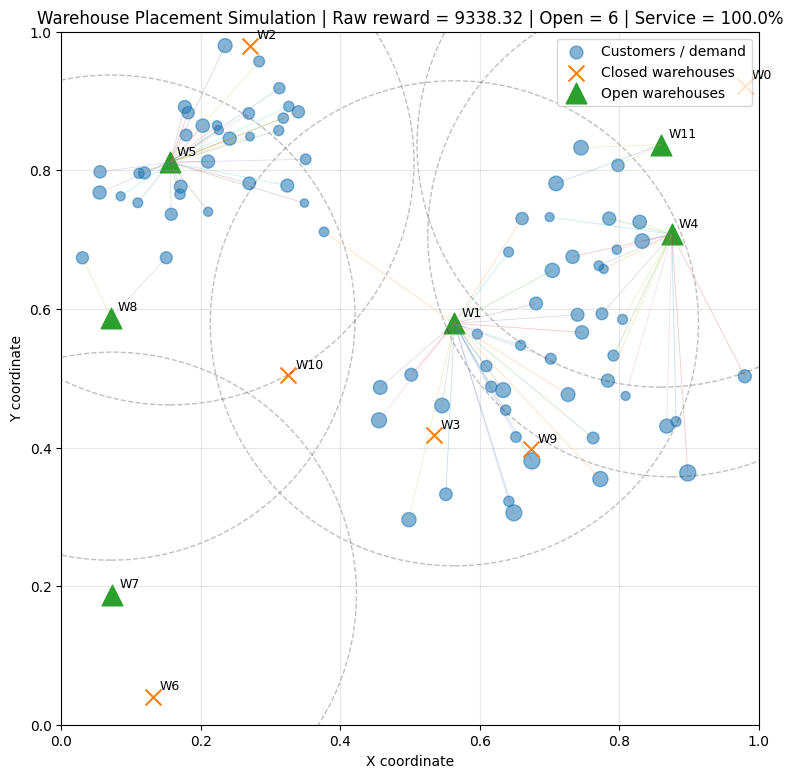

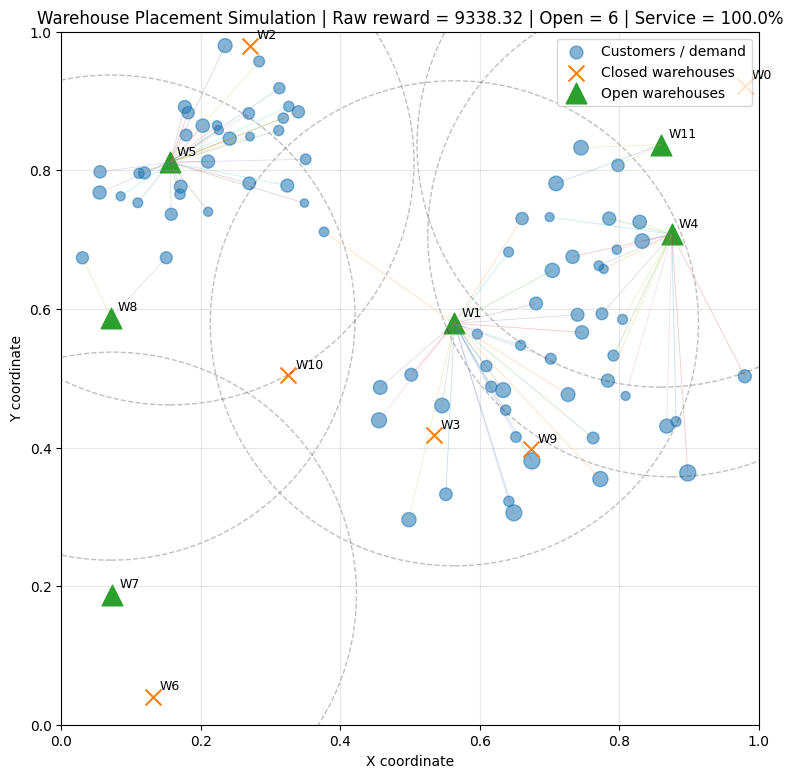

In [ ]:
# ============================================================
# TEST ENVIRONMENT
# ============================================================

test_env = WarehousePlacementGymEnv(
    n_warehouses=12,
    n_customers=80,
    max_service_distance=0.35,
    max_steps=1,
    seed=SEED,
    render_mode="human",
)

obs, info = test_env.reset()

print("Observation shape:", obs.shape)
print("Action space:", test_env.action_space)
print("Observation space:", test_env.observation_space)

random_action = test_env.sample_random_action()
print("Random action:", random_action)

obs, reward, terminated, truncated, info = test_env.step(random_action)

print("\nScaled reward:", reward)
print("Raw reward:", info["raw_reward"])
print("Terminated:", terminated)
print("\nInfo:")
for k, v in info.items():
    if k != "open_warehouses":
        print(f"{k}: {v}")

test_env.render()

## 5. Callback ghi lại reward khi train

In [ ]:
# ============================================================
# REWARD LOGGER CALLBACK
# ============================================================

class RewardLoggerCallback(BaseCallback):
    """
    Lưu episode reward trong quá trình train.
    Dùng Monitor wrapper nên info sẽ có key 'episode'.
    """

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.timesteps = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])

        for info in infos:
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.timesteps.append(self.num_timesteps)

        return True


def moving_average(values, window=20):
    values = np.array(values, dtype=np.float32)

    if len(values) < window:
        return values

    return np.convolve(values, np.ones(window) / window, mode="valid")

## 6. Train PPO

Đây là phần train chính.

Nếu muốn chạy nhanh để test, để `TOTAL_TIMESTEPS = 20_000`.

Nếu muốn kết quả tốt hơn, tăng lên `100_000` hoặc `300_000`.

In [ ]:
# ============================================================
# CREATE TRAIN ENV
# ============================================================

train_env = WarehousePlacementGymEnv(
    n_warehouses=12,
    n_customers=80,
    n_demand_clusters=3,
    max_service_distance=0.35,
    max_steps=1,
    seed=SEED,
    render_mode=None,
)

# Monitor giúp ghi episode reward
train_env = Monitor(train_env)

callback = RewardLoggerCallback()

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=256,
    n_epochs=10,
    gamma=0.95,
    gae_lambda=0.90,
    clip_range=0.2,
    ent_coef=0.02,
    vf_coef=0.5,
    verbose=1,
    seed=SEED,
)

print("Model created successfully")

Using cpu device
Wrapping the env in a DummyVecEnv.
Model created successfully


In [ ]:
# ============================================================
# TRAIN MODEL
# ============================================================

TOTAL_TIMESTEPS = 100_000

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
)

print("Training done!")

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | 6.76     |
| time/              |          |
|    fps             | 303      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 512      |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 1          |
|    ep_rew_mean          | 7.48       |
| time/                   |            |
|    fps                  | 289        |
|    iterations           | 2          |
|    time_elapsed         | 3          |
|    total_timesteps      | 1024       |
| train/                  |            |
|    approx_kl            | 0.01910635 |
|    clip_fraction        | 0.111      |
|    clip_range           | 0.2        |
|    entropy_loss         | -8.31      |
|    explained_variance   | -0.00602   |
|    learning_rate        | 0.0003     |
|   

## 7. Vẽ biểu đồ reward sau khi train

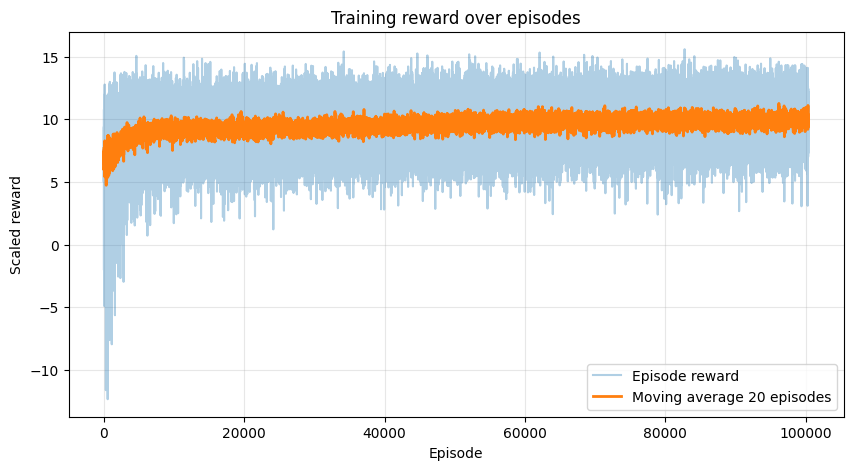

Number of finished episodes: 100352
Mean reward last 50 episodes: 9.996992


In [ ]:
# ============================================================
# PLOT TRAINING REWARD
# ============================================================

plt.figure(figsize=(10, 5))

if len(callback.episode_rewards) > 0:
    rewards = np.array(callback.episode_rewards, dtype=np.float32)

    plt.plot(rewards, alpha=0.35, label="Episode reward")

    if len(rewards) >= 20:
        ma = moving_average(rewards, window=20)
        plt.plot(
            np.arange(len(ma)) + 19,
            ma,
            linewidth=2,
            label="Moving average 20 episodes",
        )

    plt.title("Training reward over episodes")
    plt.xlabel("Episode")
    plt.ylabel("Scaled reward")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("Number of finished episodes:", len(rewards))
    print("Mean reward last 50 episodes:", np.mean(rewards[-50:]))
else:
    print("Chưa có episode reward nào được log. Hãy train lâu hơn hoặc kiểm tra callback.")

## 8. So sánh Random Policy và PPO Policy

Cell này đánh giá xem policy sau train có tốt hơn chọn ngẫu nhiên không.

In [ ]:
# ============================================================
# CUSTOM EVALUATION
# ============================================================

def evaluate_random_policy(n_episodes=100, seed=123):
    rewards = []
    service_rates = []
    n_open_list = []

    for ep in range(n_episodes):
        env = WarehousePlacementGymEnv(
            n_warehouses=12,
            n_customers=80,
            n_demand_clusters=3,
            max_service_distance=0.35,
            max_steps=1,
            seed=seed + ep,
        )

        obs, info = env.reset()
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)

        rewards.append(info["raw_reward"])
        service_rates.append(info["service_rate"])
        n_open_list.append(info["n_open_warehouses"])

    return {
        "mean_raw_reward": float(np.mean(rewards)),
        "std_raw_reward": float(np.std(rewards)),
        "mean_service_rate": float(np.mean(service_rates)),
        "mean_open_warehouses": float(np.mean(n_open_list)),
    }


def evaluate_trained_policy(model, n_episodes=100, seed=123):
    rewards = []
    service_rates = []
    n_open_list = []

    for ep in range(n_episodes):
        env = WarehousePlacementGymEnv(
            n_warehouses=12,
            n_customers=80,
            n_demand_clusters=3,
            max_service_distance=0.35,
            max_steps=1,
            seed=seed + ep,
        )

        obs, info = env.reset()
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        rewards.append(info["raw_reward"])
        service_rates.append(info["service_rate"])
        n_open_list.append(info["n_open_warehouses"])

    return {
        "mean_raw_reward": float(np.mean(rewards)),
        "std_raw_reward": float(np.std(rewards)),
        "mean_service_rate": float(np.mean(service_rates)),
        "mean_open_warehouses": float(np.mean(n_open_list)),
    }


random_result = evaluate_random_policy(n_episodes=100, seed=1000)
ppo_result = evaluate_trained_policy(model, n_episodes=100, seed=1000)

comparison_df = pd.DataFrame([
    {"policy": "Random", **random_result},
    {"policy": "PPO trained", **ppo_result},
])

comparison_df

,policy,mean_raw_reward,std_raw_reward,mean_service_rate,mean_open_warehouses
0,Random,6513.885004,3725.195871,0.931055,6.03
1,PPO trained,9984.608726,1577.867966,0.996112,8.74


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


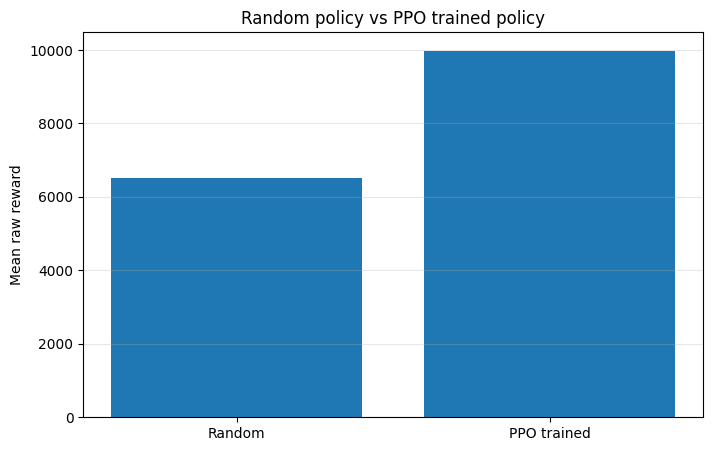

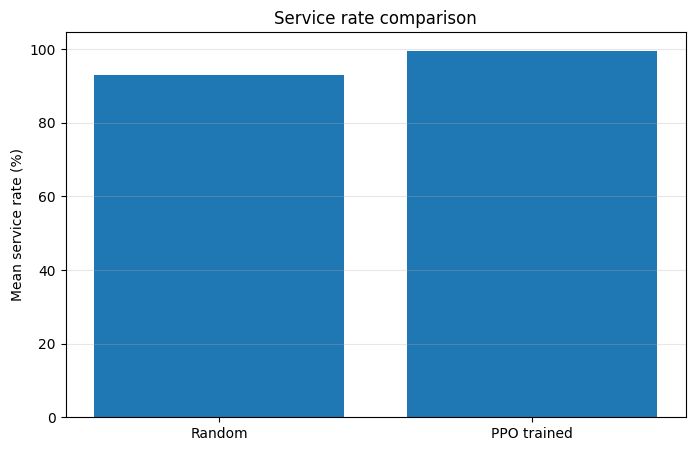

In [ ]:
# ============================================================
# BAR CHART COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["policy"], comparison_df["mean_raw_reward"])
plt.title("Random policy vs PPO trained policy")
plt.ylabel("Mean raw reward")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["policy"], comparison_df["mean_service_rate"] * 100)
plt.title("Service rate comparison")
plt.ylabel("Mean service rate (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 9. Trực quan hóa kết quả chọn kho của mô hình đã train

PPO selected action: [1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0.]

Result info:
served_demand: 1877.237548828125
unserved_demand: 41.645263671875
service_rate: 0.9782971143722534
revenue: 18772.375
opening_cost: 945.8486328125
transport_cost: 1704.46435546875
unserved_penalty: 333.162109375
idle_penalty: 0.0
low_usage_penalty: 0.0
too_many_open_penalty: 240.0
capacity_penalty: 4497.723558425903
profit: 11051.176832199097
n_open_warehouses: 7
raw_reward: 11051.176832199097
scaled_reward: 11.051176832199097
step: 1


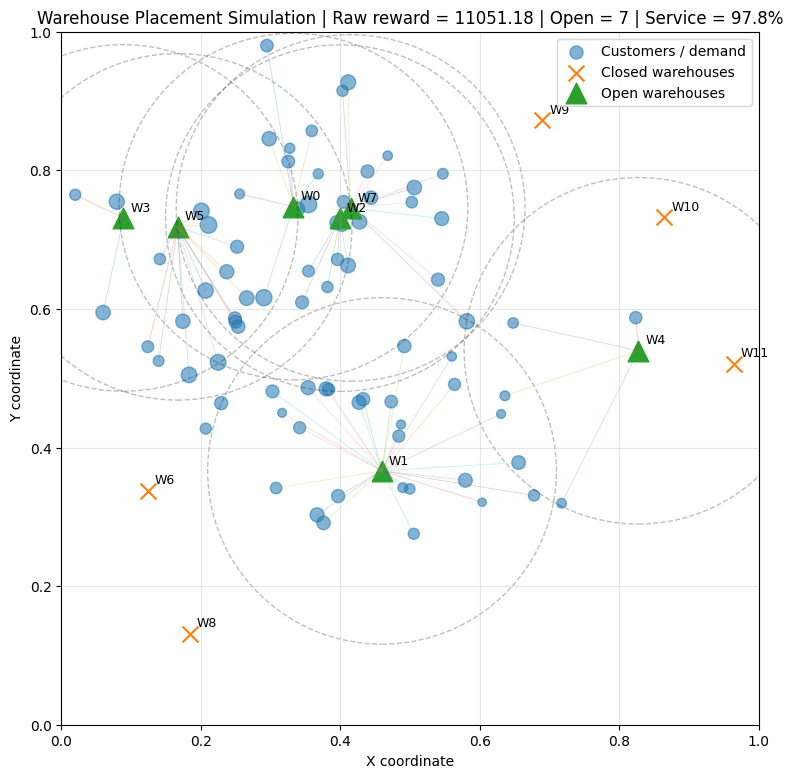

,warehouse,x,y,open,capacity,opening_cost,served_demand,n_customers_served
0,W0,0.332856,0.747688,1,212.0,147.921814,252.932098,10
1,W1,0.459859,0.366276,1,223.0,119.117035,524.783142,26
2,W2,0.399435,0.731040,1,152.0,107.510086,168.702957,7
3,W3,0.089153,0.731269,1,166.0,140.689804,86.016037,3
4,W4,0.827540,0.539622,1,176.0,158.294235,53.600540,4
5,W5,0.166731,0.718484,1,156.0,157.478745,459.452148,15
6,W6,0.124111,0.337759,0,152.0,124.215767,0.000000,0
7,W7,0.414818,0.745711,1,245.0,114.836853,331.750214,13
8,W8,0.183901,0.131461,0,138.0,137.508514,0.000000,0
9,W9,0.689565,0.872511,0,168.0,115.405365,0.000000,0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ============================================================
# VISUALIZE TRAINED POLICY ON ONE SCENARIO
# ============================================================

eval_env = WarehousePlacementGymEnv(
    n_warehouses=12,
    n_customers=80,
    n_demand_clusters=3,
    max_service_distance=0.25,
    max_steps=1,
    seed=2026,
    render_mode="human",
)

obs, info = eval_env.reset()

action, _ = model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = eval_env.step(action)

print("PPO selected action:", action)
print("\nResult info:")
for k, v in info.items():
    print(f"{k}: {v}")

eval_env.render()

solution_table = eval_env.get_solution_table()
solution_table

## 10. So sánh cùng một scenario: Random vs PPO

Cell này dùng cùng một bản đồ khách hàng/kho để so sánh trực quan.

RANDOM POLICY
Action: [0 1 0 1 0 1 0 0 0 1 1 0]
Raw reward: 7334.995429992676
Service rate: 0.904873788356781
Open warehouses: 5


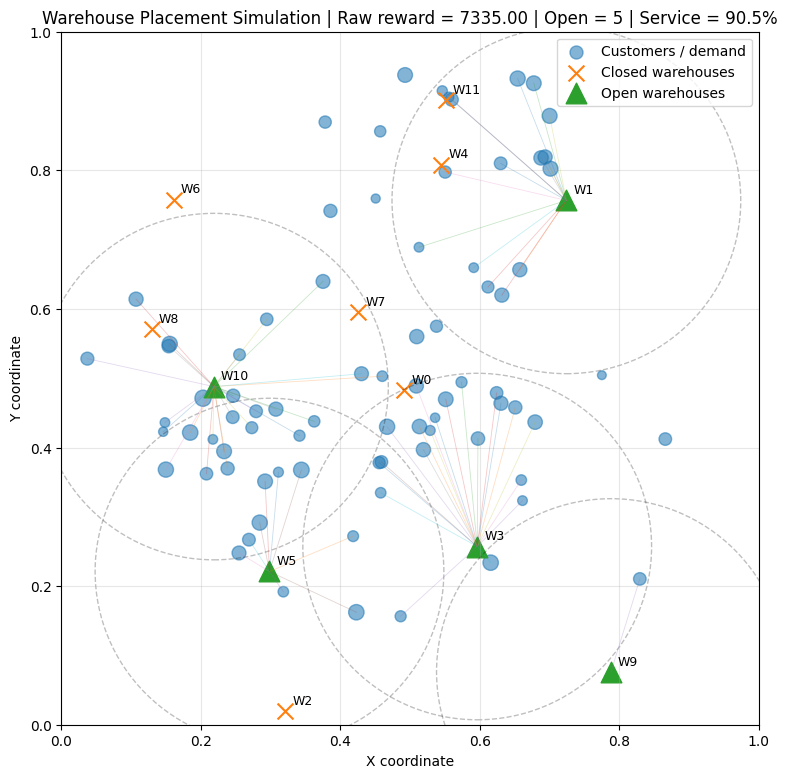


PPO TRAINED POLICY
Action: [1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0.]
Raw reward: 10913.267923355103
Service rate: 0.9854103922843933
Open warehouses: 9


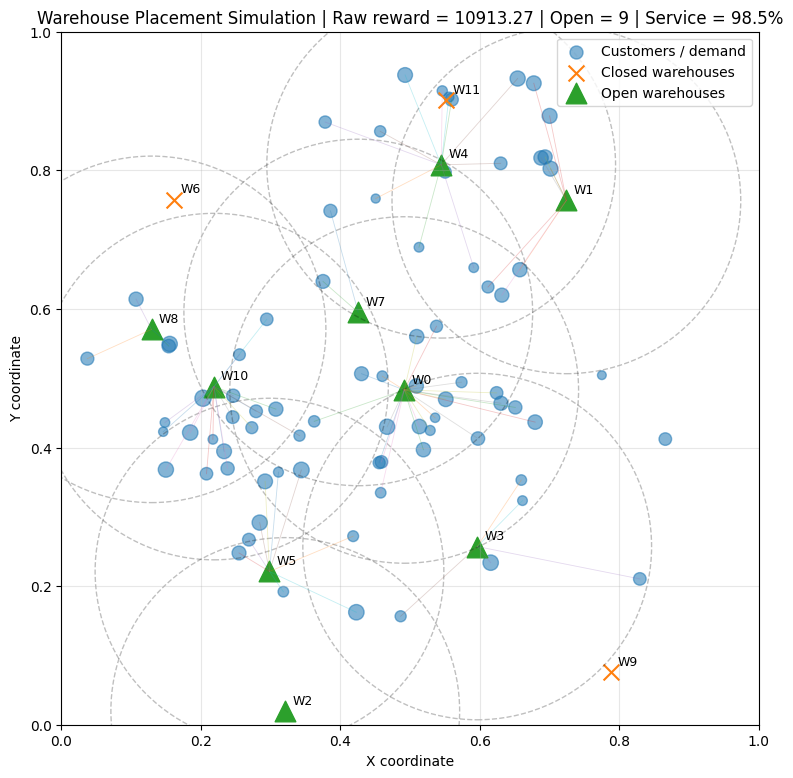

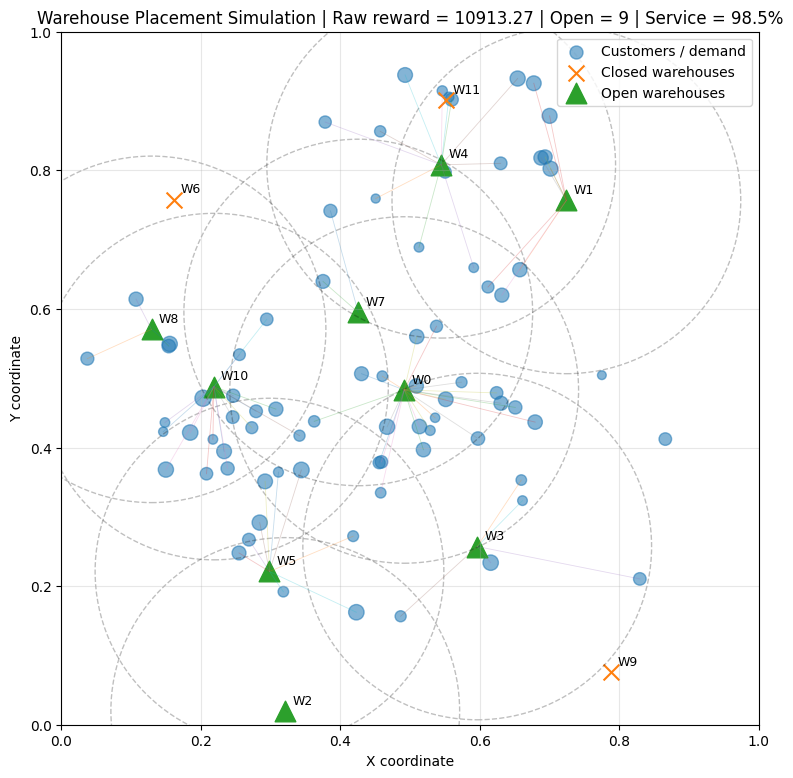

In [ ]:
# ============================================================
# VISUAL COMPARISON: RANDOM VS PPO ON SAME SEED
# ============================================================

SCENARIO_SEED = 777

# Random
random_env = WarehousePlacementGymEnv(
    n_warehouses=12,
    n_customers=80,
    n_demand_clusters=3,
    max_service_distance=0.25,
    max_steps=1,
    seed=SCENARIO_SEED,
    render_mode="human",
)

obs, info = random_env.reset()
random_action = random_env.action_space.sample()
obs, reward, terminated, truncated, random_info = random_env.step(random_action)

print("RANDOM POLICY")
print("Action:", random_action)
print("Raw reward:", random_info["raw_reward"])
print("Service rate:", random_info["service_rate"])
print("Open warehouses:", random_info["n_open_warehouses"])

random_env.render()

# PPO
ppo_env = WarehousePlacementGymEnv(
    n_warehouses=12,
    n_customers=80,
    n_demand_clusters=3,
    max_service_distance=0.25,
    max_steps=1,
    seed=SCENARIO_SEED,
    render_mode="human",
)

obs, info = ppo_env.reset()
ppo_action, _ = model.predict(obs, deterministic=True)
obs, reward, terminated, truncated, ppo_info = ppo_env.step(ppo_action)

print("\nPPO TRAINED POLICY")
print("Action:", ppo_action)
print("Raw reward:", ppo_info["raw_reward"])
print("Service rate:", ppo_info["service_rate"])
print("Open warehouses:", ppo_info["n_open_warehouses"])

ppo_env.render()

## 11. Lưu và load lại model

In [ ]:
# ============================================================
# SAVE MODEL
# ============================================================

MODEL_PATH = "ppo_marl_warehouse_gymnasium"

model.save(MODEL_PATH)

print(f"Saved model to: {MODEL_PATH}.zip")

Saved model to: ppo_marl_warehouse_gymnasium.zip


In [ ]:
# ============================================================
# LOAD MODEL TEST
# ============================================================

loaded_model = PPO.load(MODEL_PATH)

test_env = WarehousePlacementGymEnv(seed=999)
obs, info = test_env.reset()

action, _ = loaded_model.predict(obs, deterministic=True)

obs, reward, terminated, truncated, info = test_env.step(action)

print("Loaded model action:", action)
print("Raw reward:", info["raw_reward"])
print("Service rate:", info["service_rate"])

Loaded model action: [1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 0. 0.]
Raw reward: 7911.755831718445
Service rate: 0.9886348843574524
